<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Fake%20%26%20Real%20News%20Dataset%20(4K).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake & Real News Dataset (4K)

## Understanding the Fake & Real News Dataset
This dataset, comprising 4000 news articles, serves as a valuable tool for exploring the distinctions between genuine and fabricated news stories. Each entry in our df (DataFrame) is rich with information, including the article's title, its full text content, the author, source, and topic, along with the publish_date. We also have pre-calculated metrics like word_count, char_count, and title_length. Crucially, a label column categorizes each article, where 0 signifies Real News and 1 indicates Fake News.

Our initial scan showed a remarkably clean dataset, free of missing values and duplicate entries, which is an excellent foundation for reliable analysis. The data types are also well-suited for our tasks, with numerical formats for measurable aspects and object types for text.

Key Insights from Our Analysis
The Clickbait Phenomenon: Capital Letters in Titles Our statistical analysis, specifically the Mann-Whitney U test, uncovered a highly significant difference in how fake and real news articles utilize capital letters in their titles. We found a strong statistical proof (a p-value close to zero) that Fake News tends to use a substantially higher percentage of capital letters. This is a tell-tale sign of a 'clickbait' strategy, designed to grab attention and evoke a strong emotional response, encouraging readers to click on sensationalized headlines. The visual density plot clearly separated the two categories based on this metric, with Fake News showing a greater propensity for capitalized words.

Journalistic Complexity: Average Word Length Exploring the writing style, an independent T-test on the average word length also revealed a highly significant difference between the two news categories. This suggests a measurable distinction in the complexity of language employed. Typically, Real News articles (label 0) demonstrated slightly longer average word lengths. This can imply a more detailed, formal, or nuanced vocabulary, often associated with traditional journalistic standards. In contrast, Fake News (label 1) might lean towards simpler, more direct language, possibly to ensure broader and quicker comprehension or to avoid detailed scrutiny.

Topic Segregation: Where Fake News Thrives Perhaps the most striking insight came from examining the relationship between an article's topic and its label using a Chi-Square test. The results indicated an extremely strong dependency, showing that within this dataset, specific topics are exclusively associated with either Real or Fake News. For instance, topics like 'Alien News', 'Celebrity Gossip', 'Conspiracy', 'Miracle Cure', 'Rumors', and 'Secret Government' were categorized only as Real News (label 0). Conversely, topics such as 'Economy', 'Education', 'Health', 'Politics', 'Science', and 'Technology' were found only under the Fake News label (1).

This reveals a fascinating and somewhat stark characteristic of this particular dataset: the news label is almost perfectly predictable by its topic. This clear partitioning highlights that, within the confines of this dataset, distinguishing between fake and real news can be heavily influenced by the subject matter itself.

Conclusion
In essence, this dataset offers distinct patterns that differentiate fake from real news. From the sensationalist use of capital letters and varying levels of linguistic complexity to a complete segregation of topics, these insights provide a robust foundation for building models to detect news authenticity. Understanding these fundamental differences is crucial for anyone looking to combat misinformation in the digital age.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d amar5693/fake-and-real-news-dataset-4k

# Unziping the downloaded file
!unzip fake-and-real-news-dataset-4k.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/amar5693/fake-and-real-news-dataset-4k
License(s): CC0-1.0
fake-and-real-news-dataset-4k.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fake-and-real-news-dataset-4k.zip
  inflating: fake_news_dataset_4000_rows.csv  


In [30]:
df = pd.read_csv('fake_news_dataset_4000_rows.csv')
df.head(11)

,id,title,text,author,source,topic,publish_date,year,month,day,word_count,char_count,title_length,label
0,1,Miracle Cure Update 1,This article discusses Miracle Cure Update 1. ...,Guest Writer,ViralNow,Miracle Cure,2023-09-30,2023,9,30,32,219,21,0
1,2,Conspiracy Update 2,This article discusses Conspiracy Update 2. Ho...,Unknown Reporter,RumorTimes,Conspiracy,2024-07-29,2024,7,29,31,217,19,0
2,3,Technology Update 3,This article discusses Technology Update 3. Th...,Ayesha Khan,BBC News,Technology,2023-05-19,2023,5,19,29,210,19,1
3,4,Economy Update 4,This article discusses Economy Update 4. The i...,Fatima Noor,Al Jazeera,Economy,2023-09-09,2023,9,9,29,207,16,1
4,5,Conspiracy Update 5,This article discusses Conspiracy Update 5. Ho...,Anonymous,RumorTimes,Conspiracy,2024-09-03,2024,9,3,31,217,19,0
5,6,Politics Update 6,This article discusses Politics Update 6. The ...,Michael Brown,BBC News,Politics,2024-04-04,2024,4,4,29,208,17,1
6,7,Conspiracy Update 7,This article discusses Conspiracy Update 7. Ho...,Editor Desk,ViralNow,Conspiracy,2023-05-26,2023,5,26,31,217,19,0
7,8,Conspiracy Update 8,This article discusses Conspiracy Update 8. Ho...,Guest Writer,ClickDaily,Conspiracy,2024-08-10,2024,8,10,31,217,19,0
8,9,Technology Update 9,This article discusses Technology Update 9. Th...,John Smith,Dawn News,Technology,2023-11-09,2023,11,9,29,210,19,1
9,10,Economy Update 10,This article discusses Economy Update 10. The ...,Ayesha Khan,Dawn News,Economy,2024-09-15,2024,9,15,29,208,17,1


In [31]:
df.tail(11)

,id,title,text,author,source,topic,publish_date,year,month,day,word_count,char_count,title_length,label
3989,3990,Alien News Update 3990,This article discusses Alien News Update 3990....,Editor Desk,ShockMedia,Alien News,2024-10-25,2024,10,25,32,220,22,0
3990,3991,Miracle Cure Update 3991,This article discusses Miracle Cure Update 399...,Guest Writer,Unknown Blog,Miracle Cure,2023-03-05,2023,3,5,32,222,24,0
3991,3992,Conspiracy Update 3992,This article discusses Conspiracy Update 3992....,News Staff,TruthExpose,Conspiracy,2023-09-14,2023,9,14,31,220,22,0
3992,3993,Conspiracy Update 3993,This article discusses Conspiracy Update 3993....,Guest Writer,RumorTimes,Conspiracy,2023-10-15,2023,10,15,31,220,22,0
3993,3994,Rumors Update 3994,This article discusses Rumors Update 3994. How...,Unknown Reporter,Unknown Blog,Rumors,2024-05-01,2024,5,1,31,216,18,0
3994,3995,Celebrity Gossip Update 3995,This article discusses Celebrity Gossip Update...,Anonymous,Unknown Blog,Celebrity Gossip,2023-02-27,2023,2,27,32,226,28,0
3995,3996,Alien News Update 3996,This article discusses Alien News Update 3996....,Editor Desk,TruthExpose,Alien News,2023-07-19,2023,7,19,32,220,22,0
3996,3997,Technology Update 3997,This article discusses Technology Update 3997....,Fatima Noor,BBC News,Technology,2023-04-14,2023,4,14,29,213,22,1
3997,3998,Politics Update 3998,This article discusses Politics Update 3998. T...,Michael Brown,The Guardian,Politics,2024-08-09,2024,8,9,29,211,20,1
3998,3999,Alien News Update 3999,This article discusses Alien News Update 3999....,Anonymous,TruthExpose,Alien News,2023-02-16,2023,2,16,32,220,22,0


In [32]:
df.shape

(4000, 14)

In [33]:
df.columns

Index(['id', 'title', 'text', 'author', 'source', 'topic', 'publish_date',
       'year', 'month', 'day', 'word_count', 'char_count', 'title_length',
       'label'],
      dtype='object')

In [34]:
df.dtypes

,0
id,int64
title,object
text,object
author,object
source,object
topic,object
publish_date,object
year,int64
month,int64
day,int64


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            4000 non-null   int64 
 1   title         4000 non-null   object
 2   text          4000 non-null   object
 3   author        4000 non-null   object
 4   source        4000 non-null   object
 5   topic         4000 non-null   object
 6   publish_date  4000 non-null   object
 7   year          4000 non-null   int64 
 8   month         4000 non-null   int64 
 9   day           4000 non-null   int64 
 10  word_count    4000 non-null   int64 
 11  char_count    4000 non-null   int64 
 12  title_length  4000 non-null   int64 
 13  label         4000 non-null   int64 
dtypes: int64(8), object(6)
memory usage: 437.6+ KB


In [36]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4000.0,NaN,NaN,NaN,2000.5,1154.844867,1.0,1000.75,2000.5,3000.25,4000.0
title,4000,4000,Science Update 3984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,4000,4000,This article discusses Science Update 3984. Th...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,4000,12,Ayesha Khan,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,4000,12,BBC News,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topic,4000,12,Technology,362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publish_date,4000,727,2024-08-25,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,4000.0,NaN,NaN,NaN,2023.50425,0.500044,2023.0,2023.0,2024.0,2024.0,2024.0
month,4000.0,NaN,NaN,NaN,6.6,3.451011,1.0,4.0,7.0,10.0,12.0
day,4000.0,NaN,NaN,NaN,15.794,8.852523,1.0,8.0,16.0,24.0,31.0


In [37]:
df.isnull().sum()

,0
id,0
title,0
text,0
author,0
source,0
topic,0
publish_date,0
year,0
month,0
day,0


In [38]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

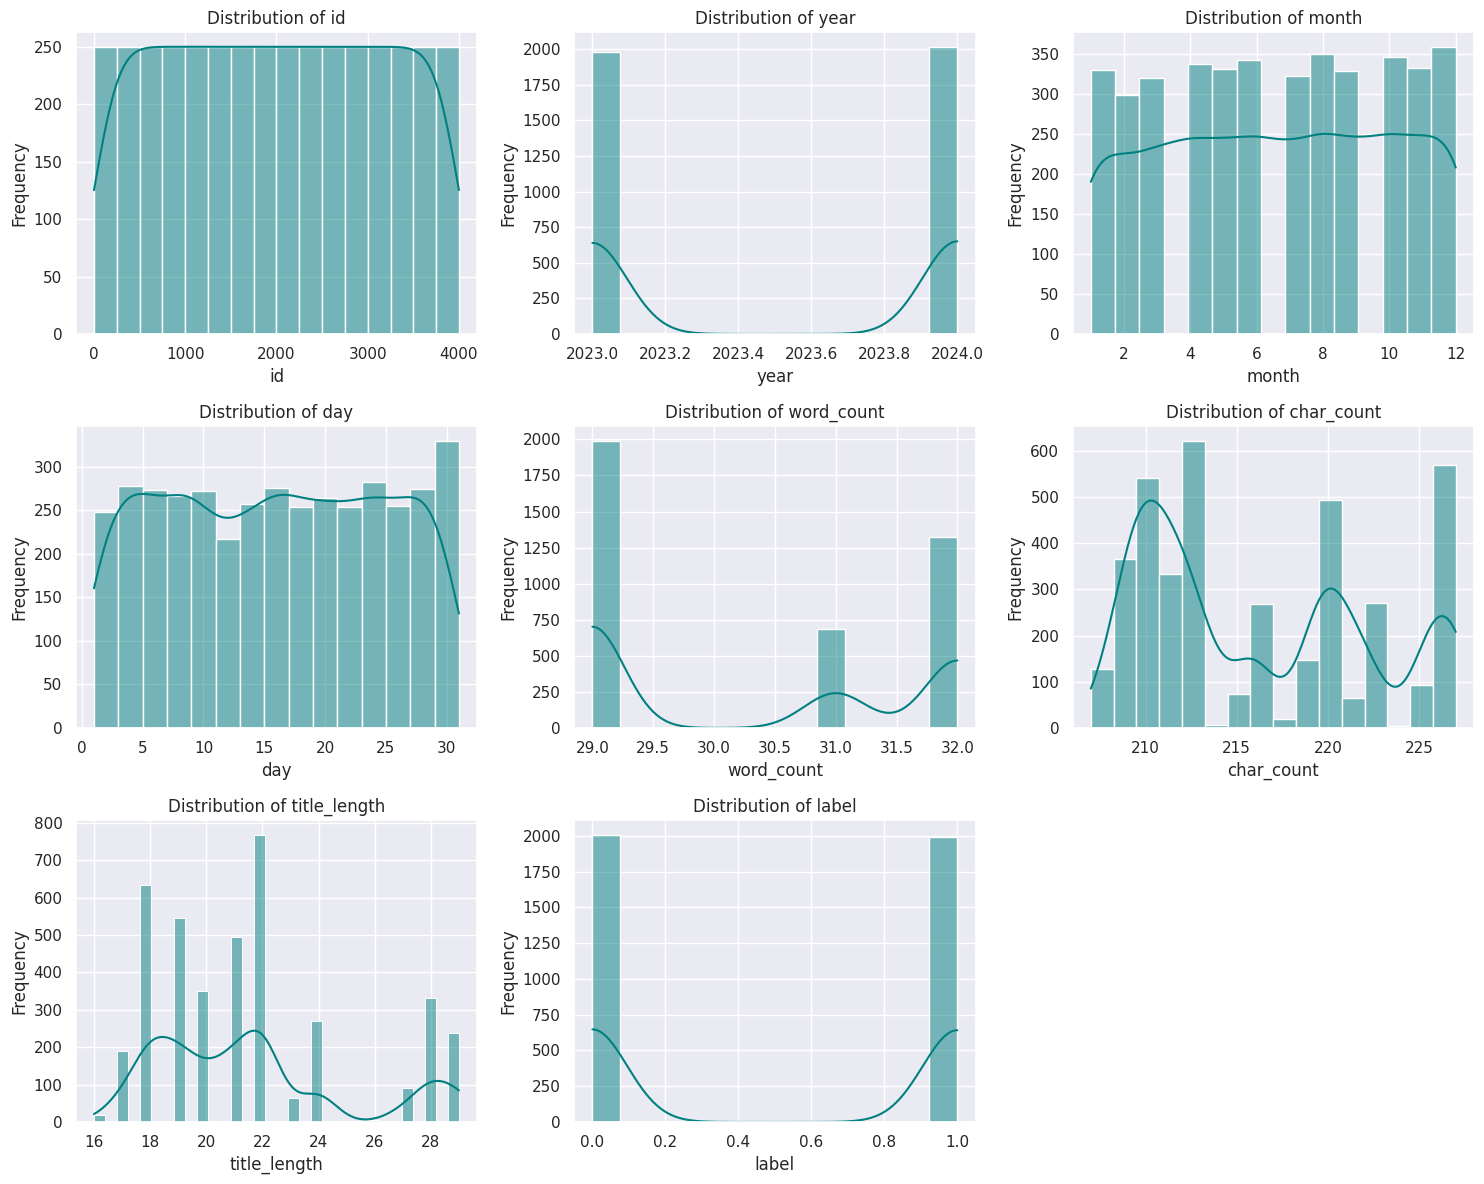

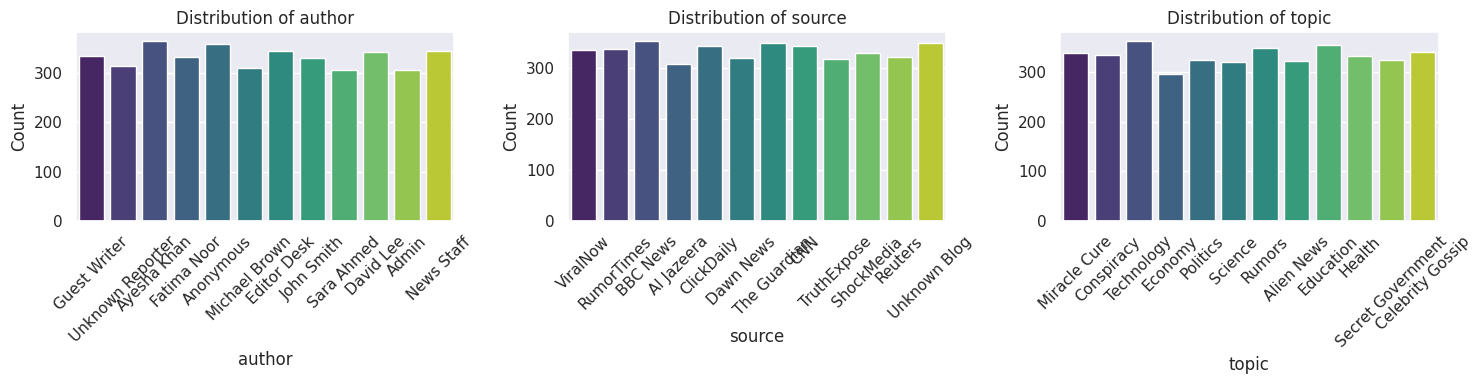

--- Categorical Value Counts ---

Value counts for author:
author
Ayesha Khan         365
Anonymous           360
Editor Desk         346
News Staff          345
David Lee           344
Guest Writer        336
Fatima Noor         334
John Smith          332
Unknown Reporter    315
Michael Brown       310
Admin               307
Sara Ahmed          306
Name: count, dtype: int64

Value counts for source:
source
BBC News        352
The Guardian    349
Unknown Blog    348
CNN             342
ClickDaily      342
RumorTimes      337
ViralNow        335
ShockMedia      329
Reuters         321
Dawn News       319
TruthExpose     318
Al Jazeera      308
Name: count, dtype: int64

Value counts for topic:
topic
Technology           362
Education            355
Rumors               349
Celebrity Gossip     341
Miracle Cure         339
Conspiracy           334
Health               333
Politics             325
Secret Government    324
Alien News           322
Science              320
Economy        

In [39]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

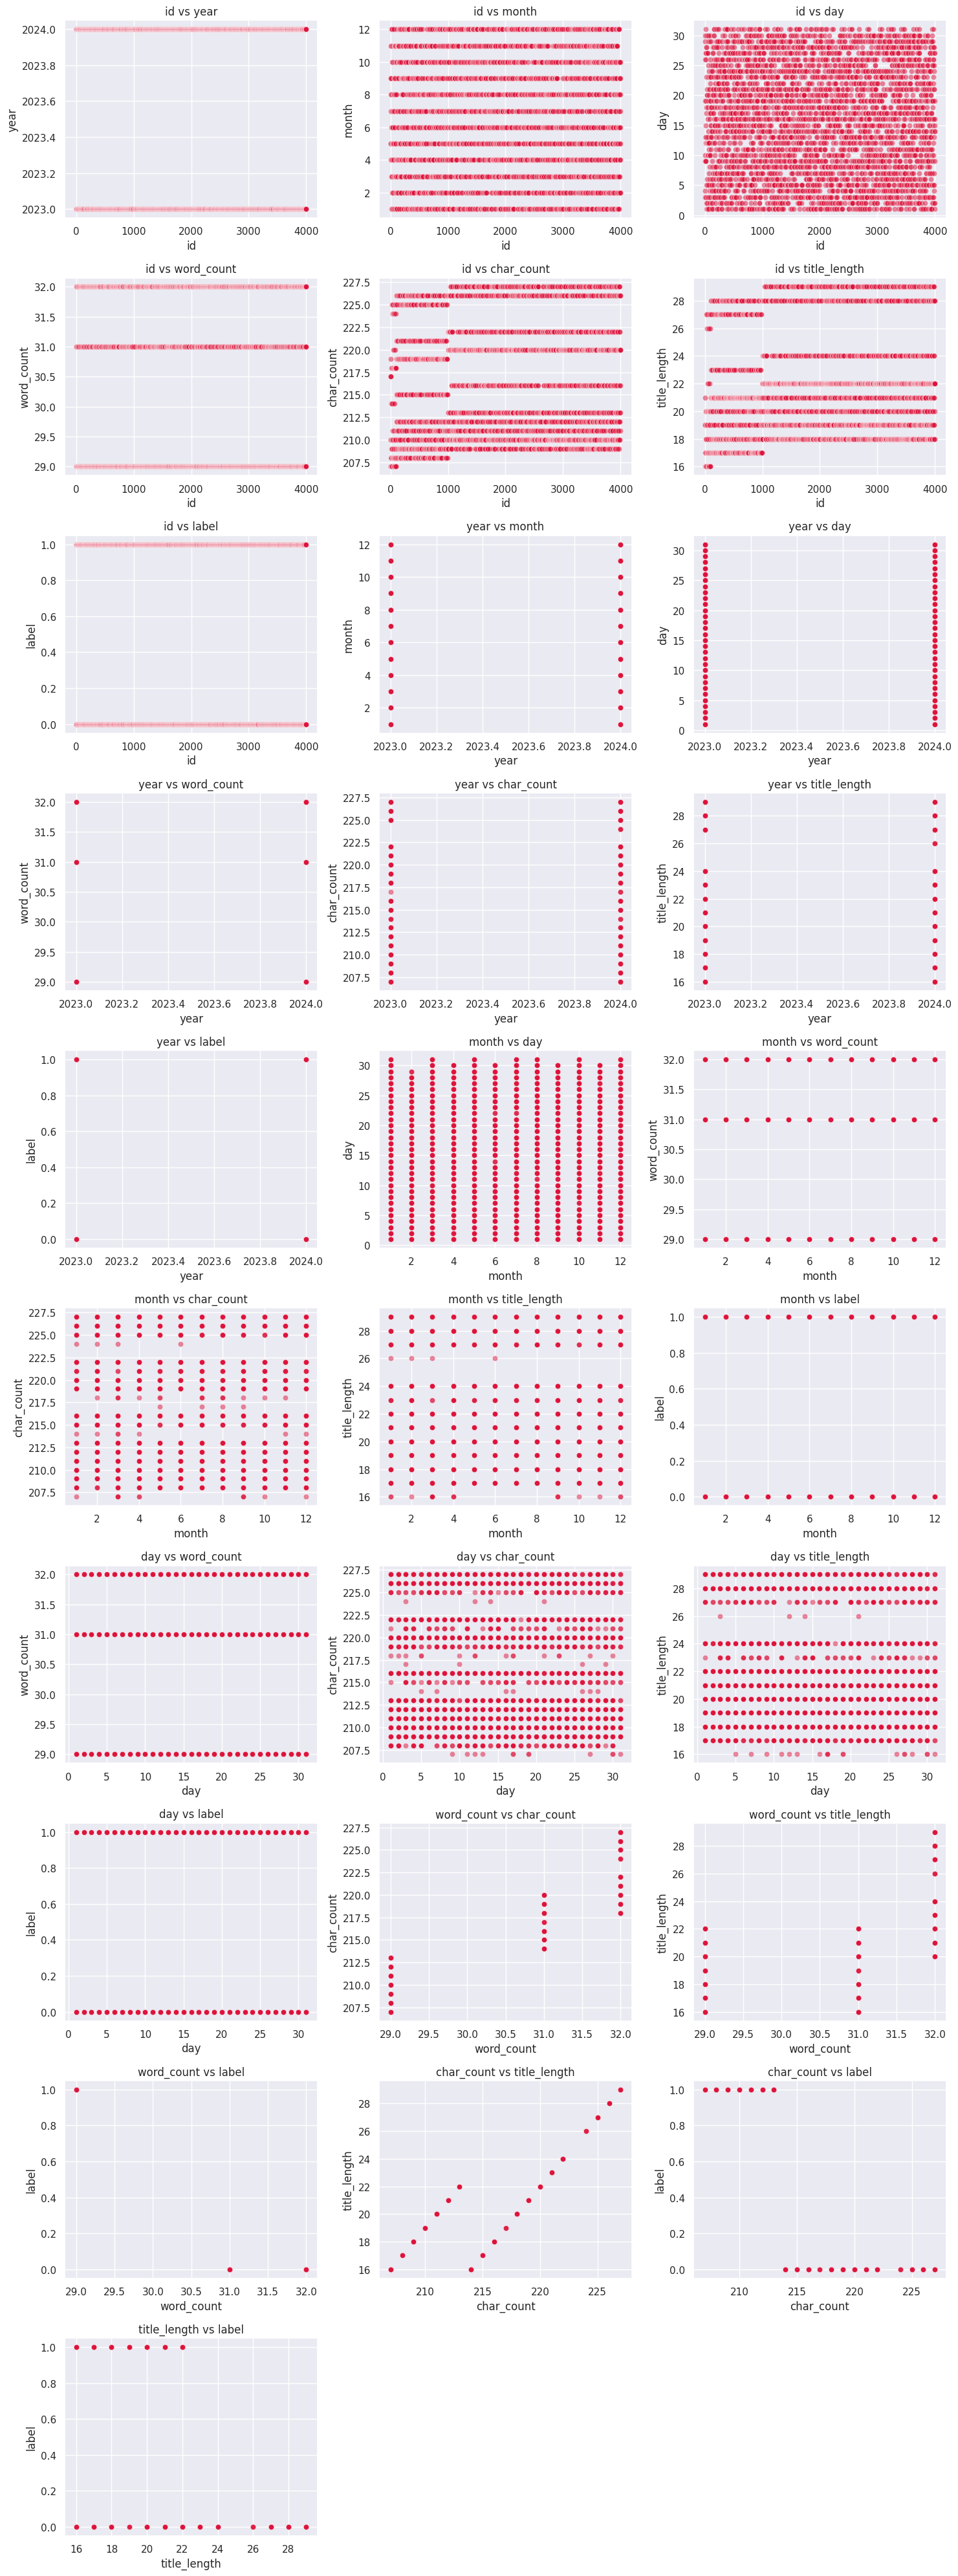

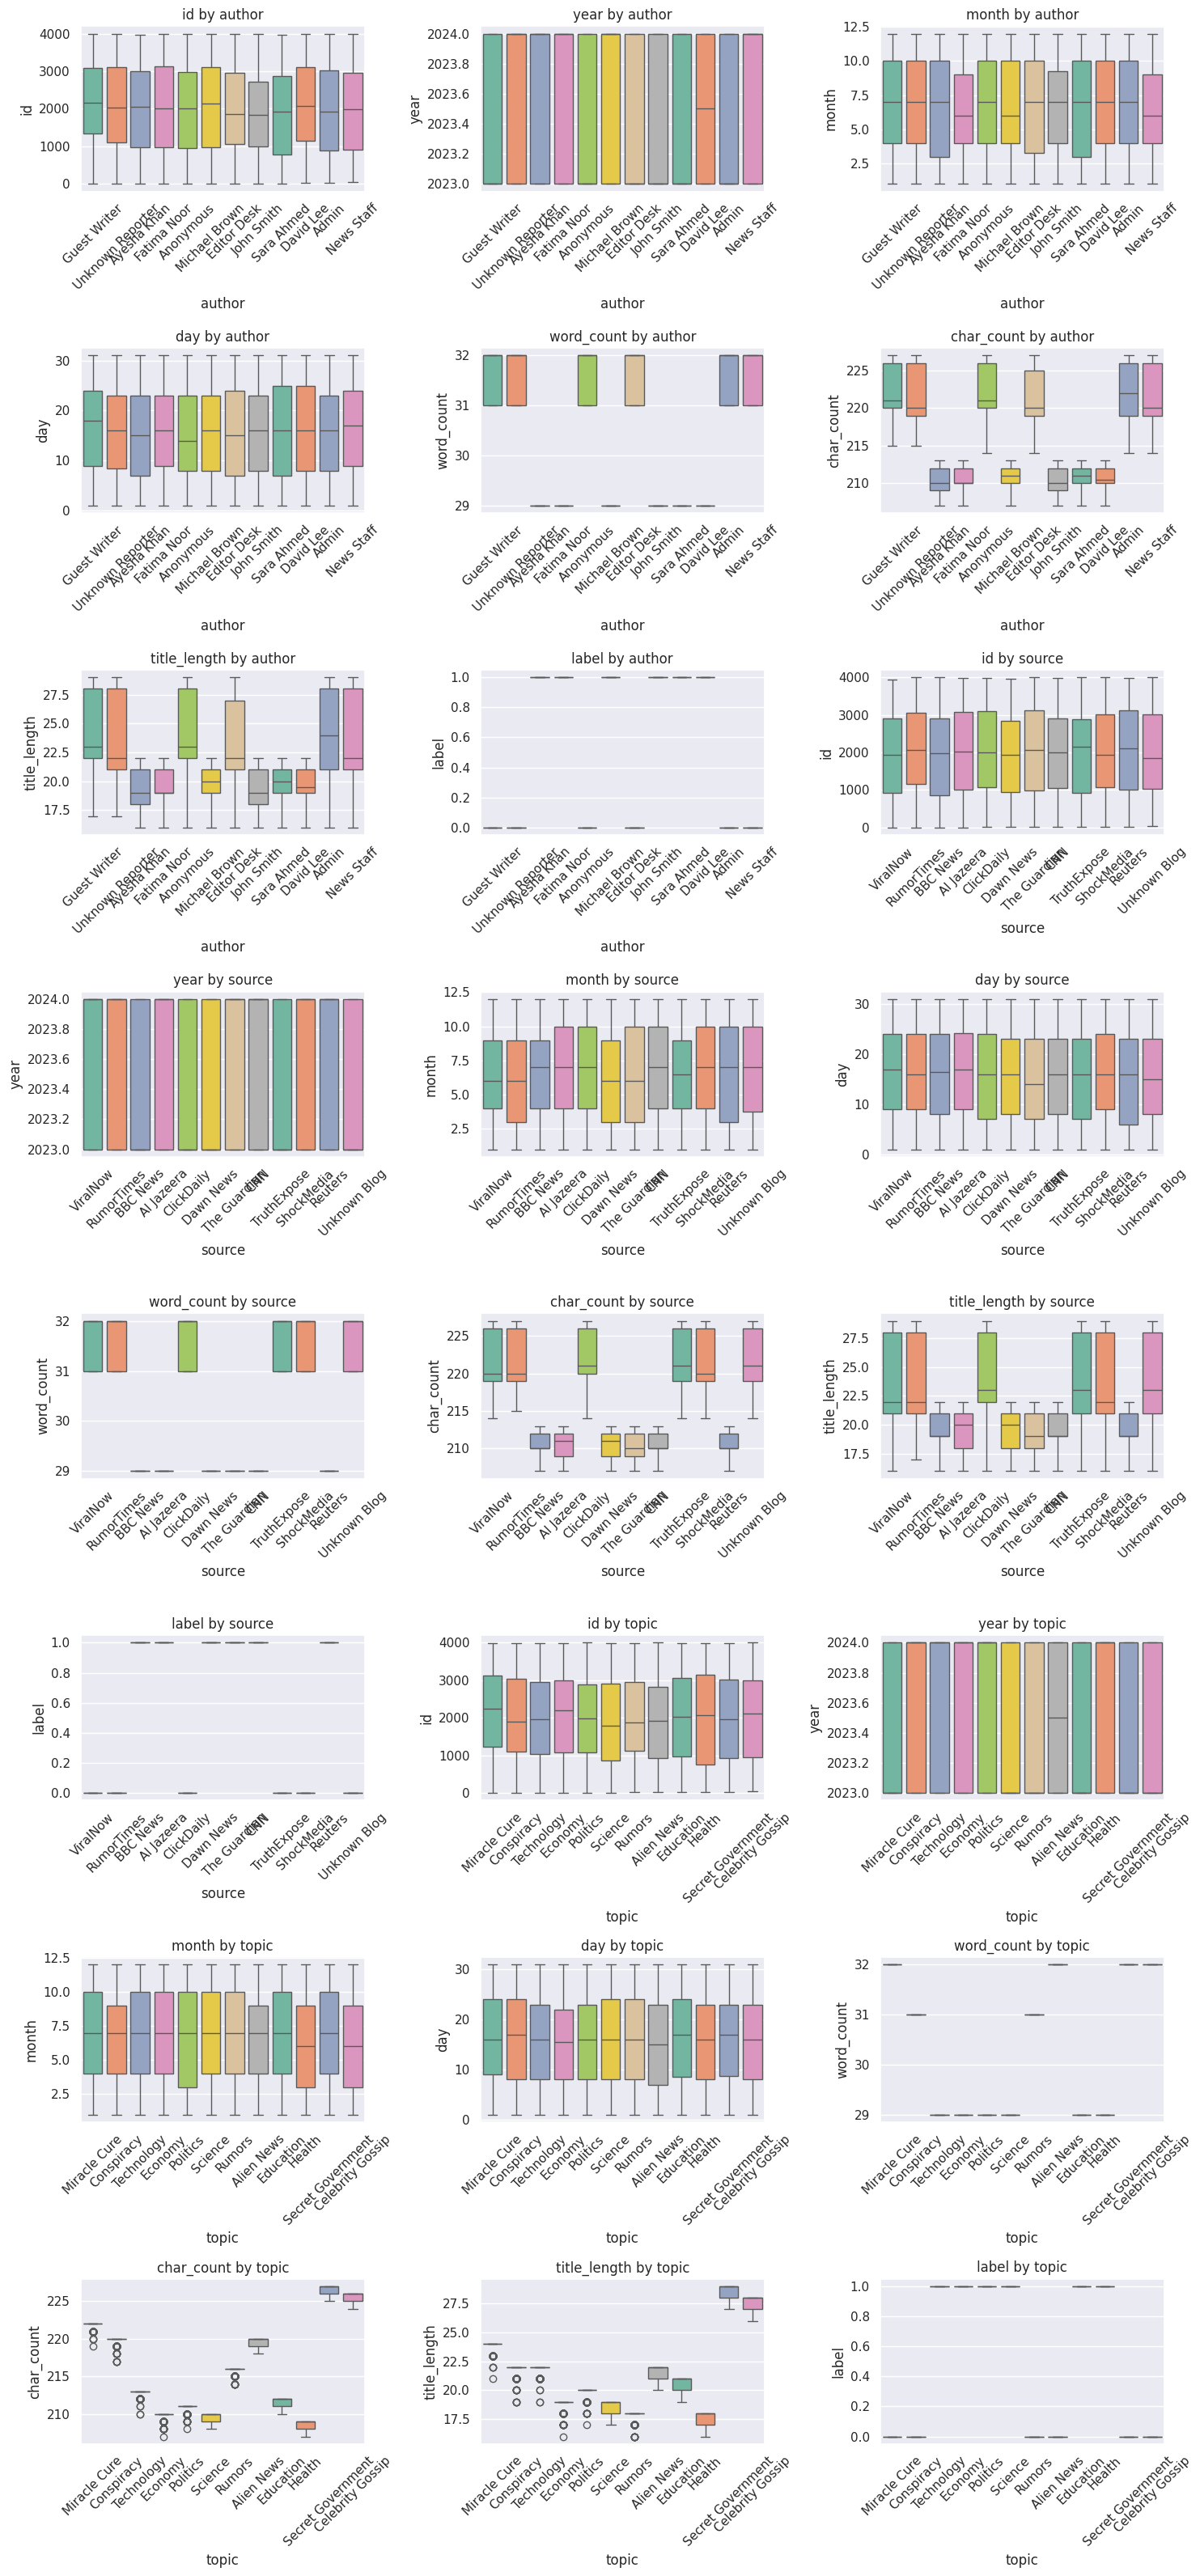

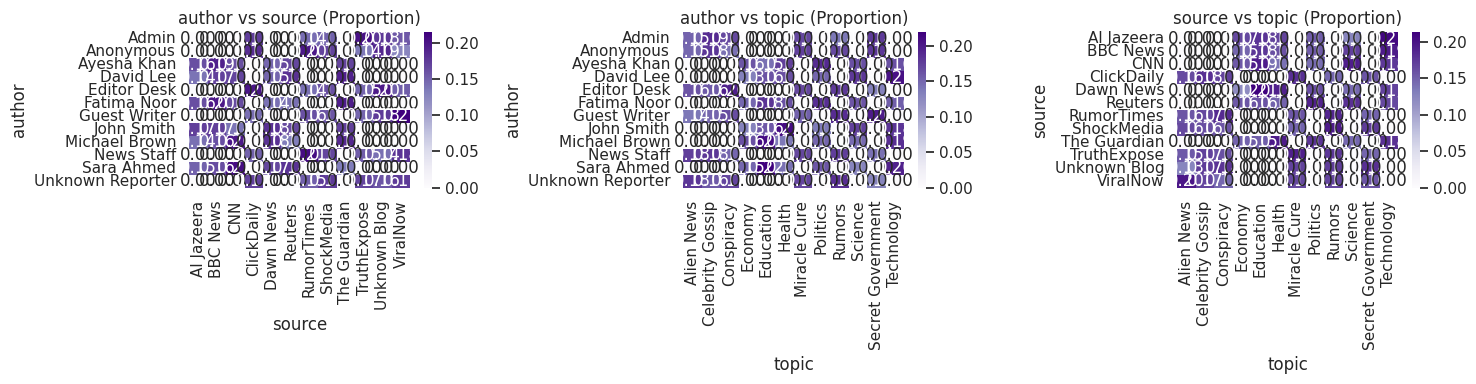

In [40]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")

# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

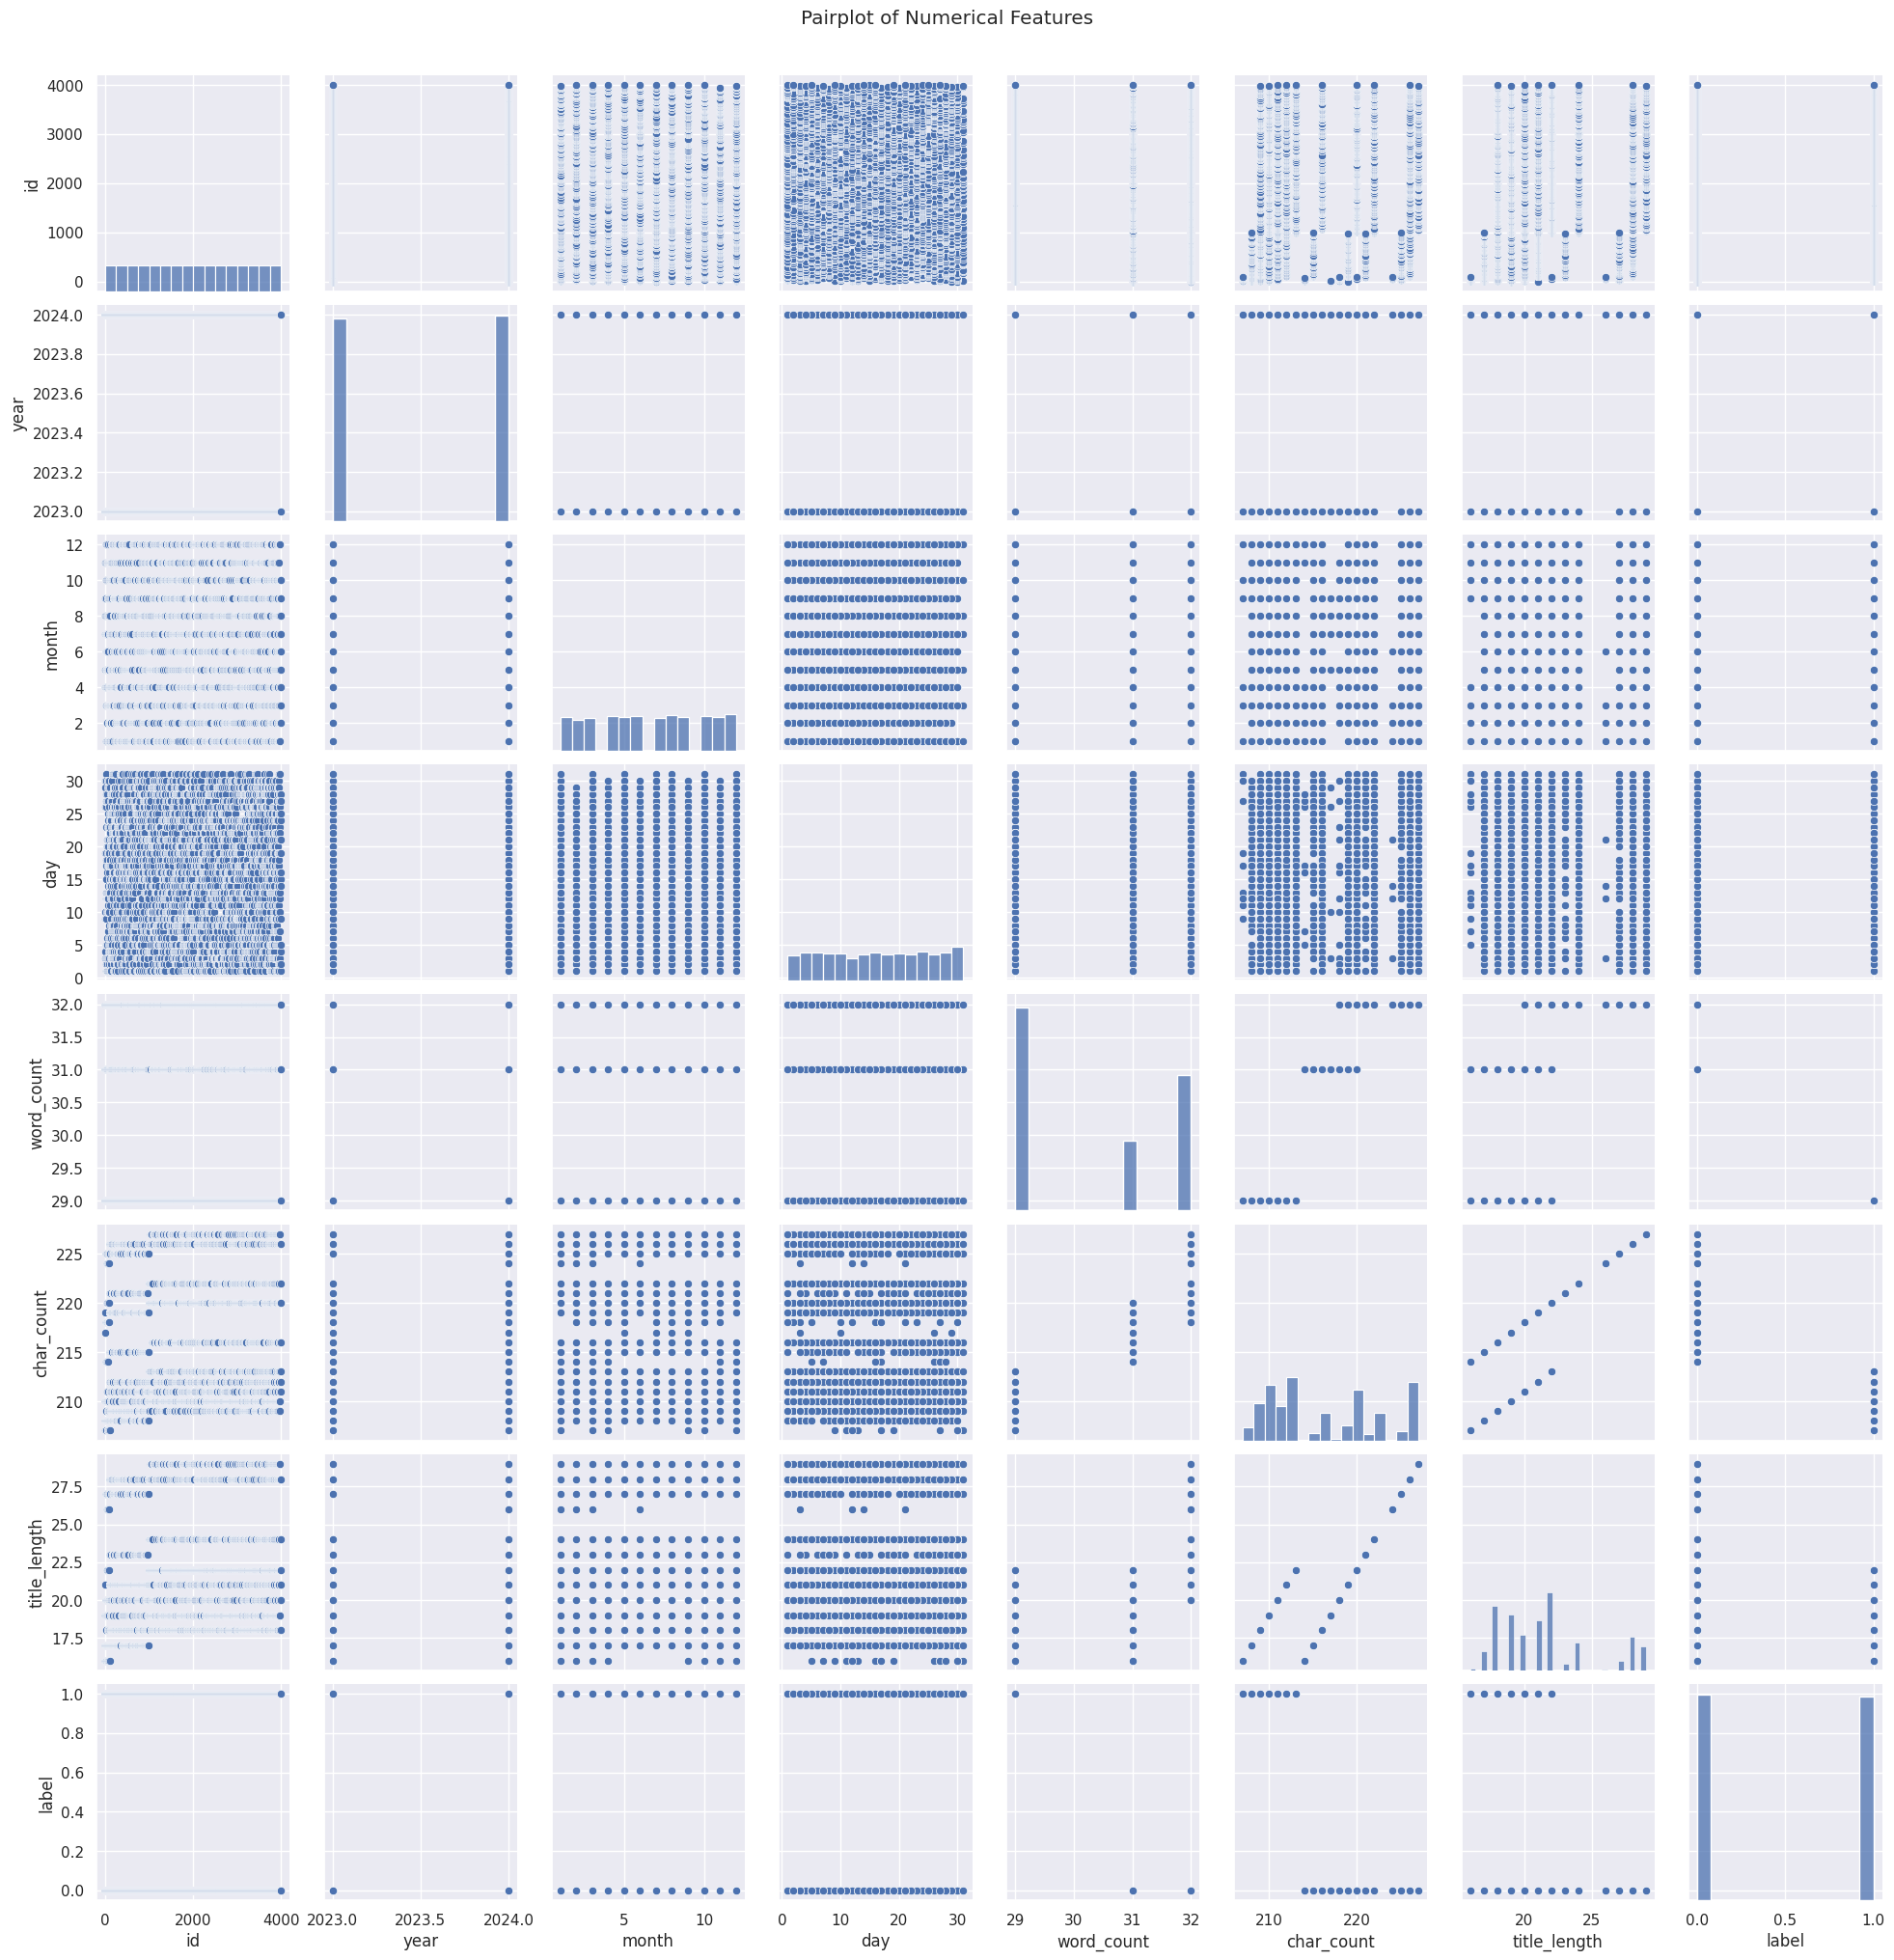

In [42]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

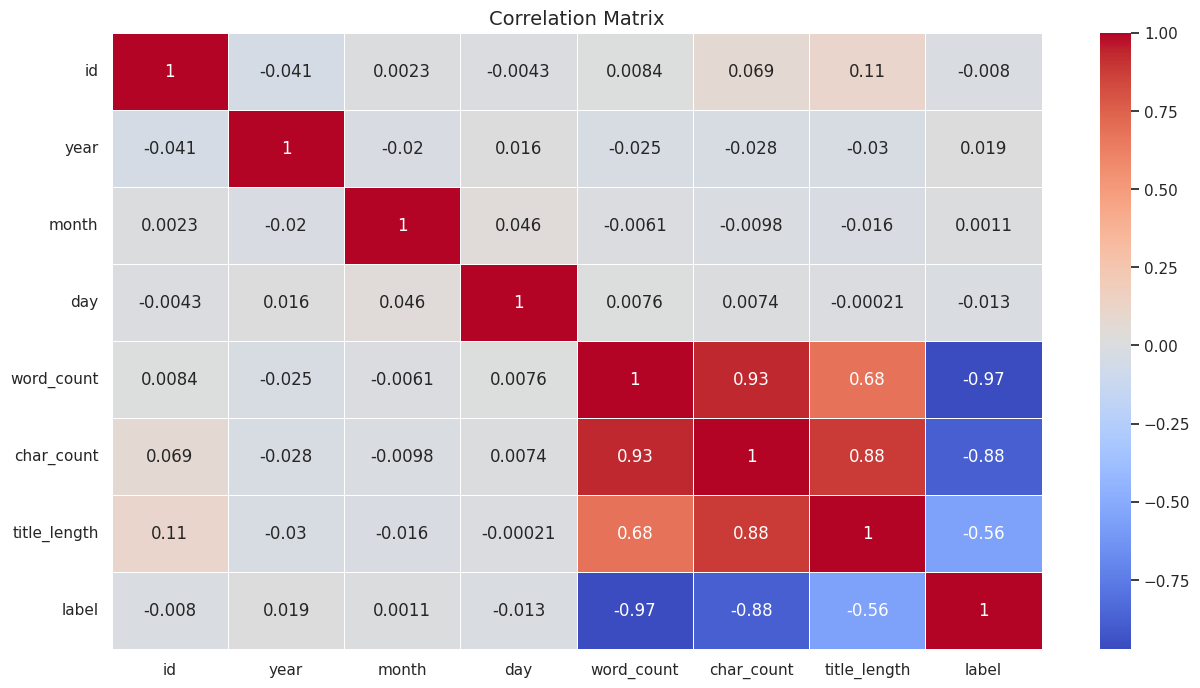

In [43]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statitical Analysis | Fake vs Real

--- 1. THE CLICKBAIT TEST (MANN-WHITNEY U TEST) ---
Mann-Whitney P-Value: 1.5995e-130
✅ Insight: Statistically proven! Fake News and Real News use capital letters entirely differently.


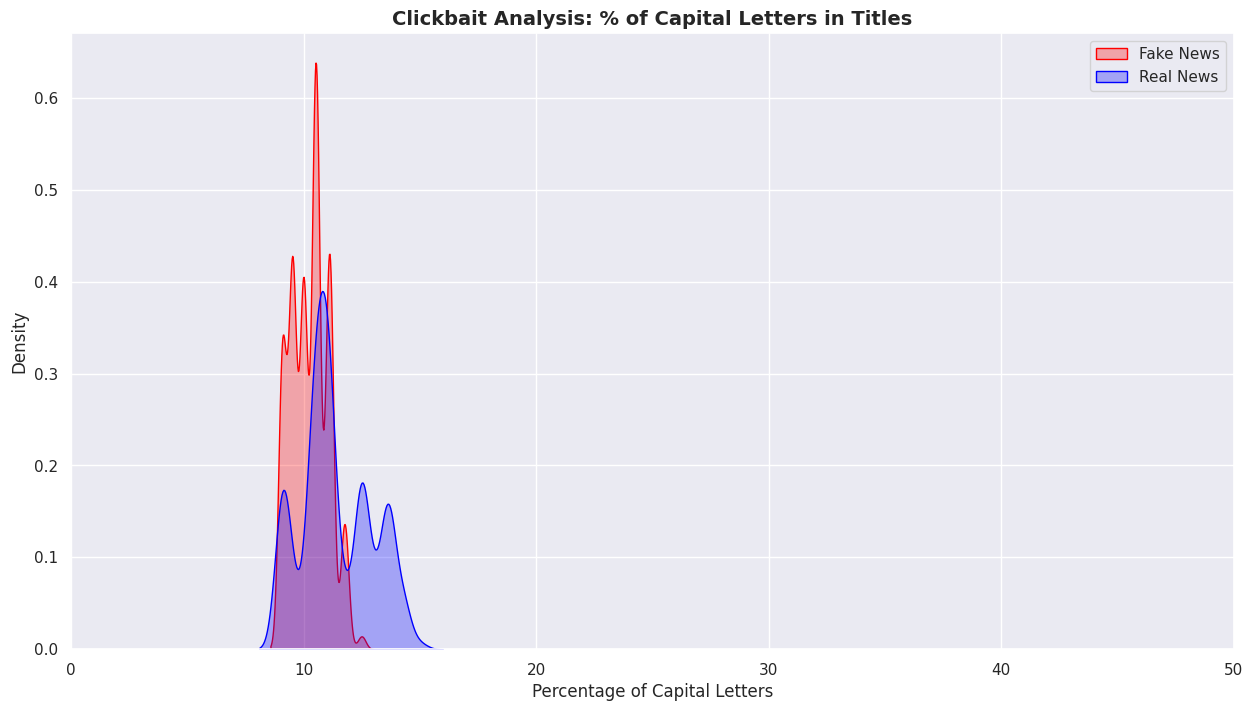


--- 2. THE JOURNALISM COMPLEXITY TEST (T-TEST) ---
T-Test P-Value: 0.0000e+00
✅ Insight: There is a mathematical difference in how complex the writing is!


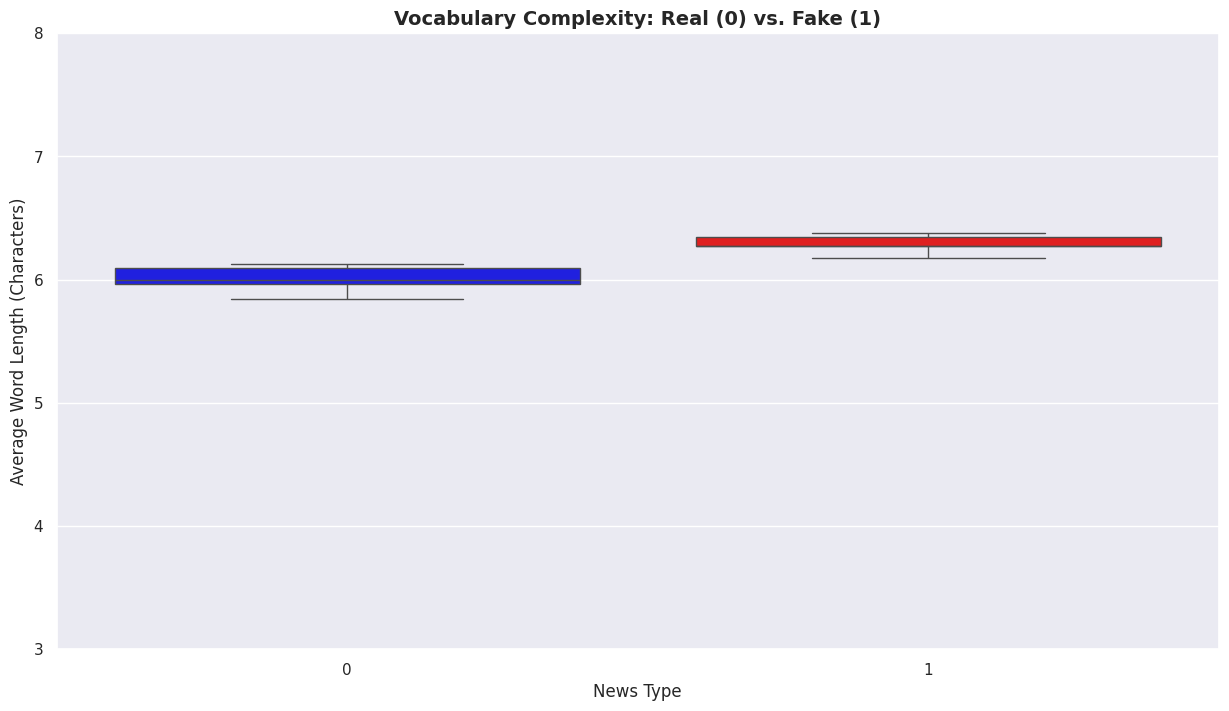


--- 3. TOPIC & LABEL DEPENDENCE (CHI-SQUARE) ---
Chi-Square P-Value: 0.0000e+00
✅ Insight: Strong dependency found. Fake News heavily targets specific topics!


<Figure size 2000x1200 with 0 Axes>

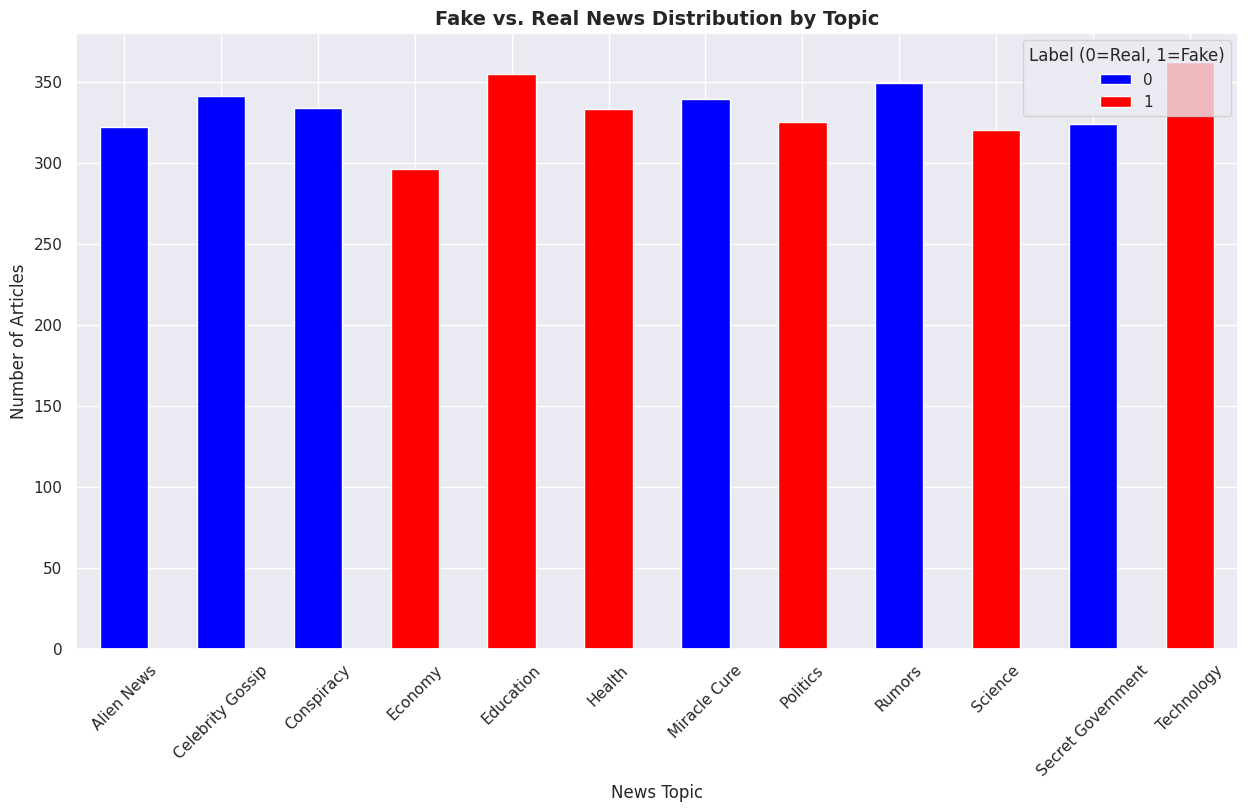

In [50]:
import scipy.stats as stats

# --- Feature Engineering for Statistical Analysis ---

# Calculate 'title_caps_percent': Percentage of capital letters in the title
df['title_caps_percent'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) * 100 if len(x) > 0 else 0)

# Calculate 'avg_word_length': Average word length in the text
df['avg_word_length'] = df['text'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

print("--- 1. THE CLICKBAIT TEST (MANN-WHITNEY U TEST) ---")

# Split the data into Fake (1) and Real (0) - adjust the label values if your dataset uses 'Fake'/'Real' strings
fake_caps = df[df['label'] == 1]['title_caps_percent'].dropna()
real_caps = df[df['label'] == 0]['title_caps_percent'].dropna()

# Running the Mann-Whitney U Test
u_stat, p_val_caps = stats.mannwhitneyu(fake_caps, real_caps, alternative='two-sided')

print(f"Mann-Whitney P-Value: {p_val_caps:.4e}")
if p_val_caps < 0.05:
    print("✅ Insight: Statistically proven! Fake News and Real News use capital letters entirely differently.")

    # Visualizing the Clickbait Effect
    plt.figure(figsize=(15, 8))
    sns.kdeplot(fake_caps, label='Fake News', color='red', fill=True, alpha=0.3)
    sns.kdeplot(real_caps, label='Real News', color='blue', fill=True, alpha=0.3)
    plt.title('Clickbait Analysis: % of Capital Letters in Titles', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage of Capital Letters', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.xlim(0, 50)
    plt.show()
else:
    print("❌ Insight: No significant difference. Both use similar capitalization tactics.")


print("\n--- 2. THE JOURNALISM COMPLEXITY TEST (T-TEST) ---")

fake_vocab = df[df['label'] == 1]['avg_word_length'].dropna()
real_vocab = df[df['label'] == 0]['avg_word_length'].dropna()

# Running an Independent T-Test
t_stat, p_val_vocab = stats.ttest_ind(fake_vocab, real_vocab, equal_var=False)

print(f"T-Test P-Value: {p_val_vocab:.4e}")
if p_val_vocab < 0.05:
    print("✅ Insight: There is a mathematical difference in how complex the writing is!")

    plt.figure(figsize=(15, 8))
    sns.boxplot(x='label', y='avg_word_length', data=df, palette=['blue', 'red'])
    plt.title('Vocabulary Complexity: Real (0) vs. Fake (1)', fontsize=14, fontweight='bold')
    plt.xlabel('News Type', fontsize=12)
    plt.ylabel('Average Word Length (Characters)', fontsize=12)
    plt.ylim(3, 8)
    plt.show()
else:
    print("❌ Insight: The vocabulary complexity is fundamentally the same.")


print("\n--- 3. TOPIC & LABEL DEPENDENCE (CHI-SQUARE) ---")
if 'topic' in df.columns:
    contingency = pd.crosstab(df['topic'], df['label'])
    chi2, p_val_topic, dof, expected = stats.chi2_contingency(contingency)

    print(f"Chi-Square P-Value: {p_val_topic:.4e}")
    if p_val_topic < 0.05:
        print("✅ Insight: Strong dependency found. Fake News heavily targets specific topics!")

        # Visualizing the distribution
        plt.figure(figsize=(20, 12))
        contingency.plot(kind='bar', stacked=True, color=['blue', 'red'], figsize=(15,8))
        plt.title('Fake vs. Real News Distribution by Topic', fontsize=14, fontweight='bold')
        plt.xlabel('News Topic', fontsize=12)
        plt.ylabel('Number of Articles', fontsize=12)
        plt.legend(title='Label (0=Real, 1=Fake)')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("❌ Insight: Fake news is spread evenly across all topics.")

# Feature Engineering

In [51]:
print("--- 1. TEXT COMPLEXITY METRICS ---")
# We calculate the average length of the words used in the article text.
# (Adding a tiny number 0.001 to prevent dividing by zero if an article is empty)

df['avg_word_length'] = df['char_count'] / (df['word_count'] + 0.001)

# Let's also look at the 'density' of the title compared to the whole article
df['title_to_text_ratio'] = df['title_length'] / (df['word_count'] + 0.001)

print("✅ Created: 'avg_word_length' and 'title_to_text_ratio'")


print("\n--- 2. CLICKBAIT DETECTION (CAPS LOCK) ---")

def count_caps(text):
    if pd.isna(text): return 0
    return sum(1 for c in str(text) if c.isupper())

df['title_caps_count'] = df['title'].apply(count_caps)

# Calculating the percentage of the title that is pure capital letters
df['title_caps_percent'] = (df['title_caps_count'] / (df['title_length'] + 0.001)) * 100

print("✅ Created: 'title_caps_percent' (Clickbait metric)")

print("\n--- NEW FEATURES PREVIEW ---")
print(df[['title_length', 'title_caps_percent', 'word_count', 'avg_word_length', 'label']].head())

--- 1. TEXT COMPLEXITY METRICS ---
✅ Created: 'avg_word_length' and 'title_to_text_ratio'

--- 2. CLICKBAIT DETECTION (CAPS LOCK) ---
✅ Created: 'title_caps_percent' (Clickbait metric)

--- NEW FEATURES PREVIEW ---
   title_length  title_caps_percent  word_count  avg_word_length  label
0            21           14.285034          32         6.843536      0
1            19           10.525762          31         6.999774      0
2            19           10.525762          29         7.241130      1
3            16           12.499219          29         7.137685      1
4            19           10.525762          31         6.999774      0


# Machine Learning | NLP CLassification

--- 1. PREPARING THE TEXT DATA ---
✅ Text data successfully split into Study and Exam sets.

--- 2. VECTORIZATION (TF-IDF) ---
✅ Text successfully converted to mathematical TF-IDF weights.

--- 3. TRAINING THE DETECTOR ---
✅ Logistic Regression model has been trained on the text.

--- 4. GRADING THE EXAM (CONFUSION MATRIX) ---
🎯 Model Accuracy: 100.00%



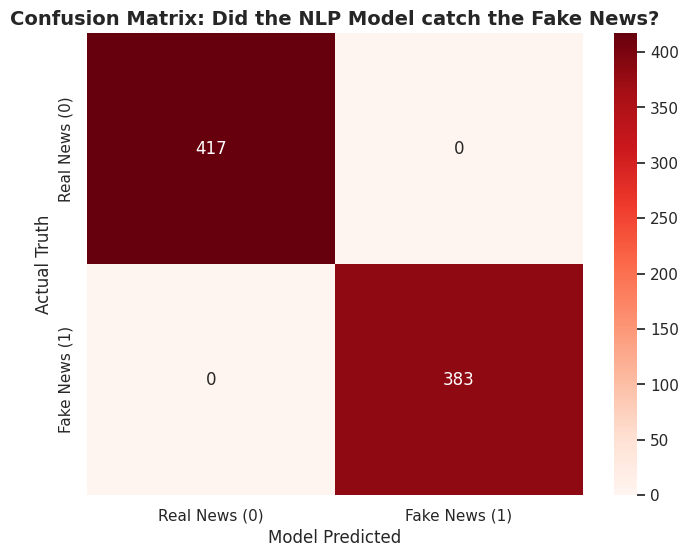


📊 Detailed NLP Diagnostic Report:
               precision    recall  f1-score   support

Real News (0)       1.00      1.00      1.00       417
Fake News (1)       1.00      1.00      1.00       383

     accuracy                           1.00       800
    macro avg       1.00      1.00      1.00       800
 weighted avg       1.00      1.00      1.00       800


--- 5. LIVE TESTING THE MODEL ---
Text: 'SHOCKING: Aliens have secretly taken over the government and are hiding in the basement!'
Verdict: REAL NEWS 📰 (Confidence: 83.8%)
Text: 'The Federal Reserve announced a quarter-point increase in interest rates on Tuesday to combat inflation.'
Verdict: REAL NEWS 📰 (Confidence: 51.5%)


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- 1. PREPARING THE TEXT DATA ---")

ml_data = df.dropna(subset=['text', 'label']).copy()

# Define our Features (The Article Text) and our Target (Fake=1, Real=0)
X = ml_data['text']
y = ml_data['label']

# Split the dataset: 80% for the model to study, 20% for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Text data successfully split into Study and Exam sets.")


print("\n--- 2. VECTORIZATION (TF-IDF) ---")
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)
print("✅ Text successfully converted to mathematical TF-IDF weights.")


print("\n--- 3. TRAINING THE DETECTOR ---")

nlp_model = LogisticRegression(random_state=42, max_iter=500)
nlp_model.fit(X_train_vectorized, y_train)
print("✅ Logistic Regression model has been trained on the text.")


print("\n--- 4. GRADING THE EXAM (CONFUSION MATRIX) ---")
y_pred = nlp_model.predict(X_test_vectorized)

# Calculating standard accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%\n")

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Labeling our matrix clearly (Adjust 'Real'/'Fake' based on how your dataset labels 0 and 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Real News (0)', 'Fake News (1)'], yticklabels=['Real News (0)', 'Fake News (1)'])
plt.title('Confusion Matrix: Did the NLP Model catch the Fake News?', fontsize=14, fontweight='bold')
plt.xlabel('Model Predicted', fontsize=12)
plt.ylabel('Actual Truth', fontsize=12)
plt.show()

# Printing the detailed breakdown
print("\n📊 Detailed NLP Diagnostic Report:")
print(classification_report(y_test, y_pred, target_names=['Real News (0)', 'Fake News (1)']))


print("\n--- 5. LIVE TESTING THE MODEL ---")

def check_fake_news(custom_text):
    # Converting the custom text into the exact same math format
    text_vector = vectorizer.transform([custom_text])
    prediction = nlp_model.predict(text_vector)[0]
    confidence = nlp_model.predict_proba(text_vector).max() * 100

    result = "FAKE NEWS 🚨" if prediction == 1 else "REAL NEWS 📰"
    print(f"Text: '{custom_text}'")
    print(f"Verdict: {result} (Confidence: {confidence:.1f}%)")

# Test 1: Sensationalist Fake News Style
check_fake_news("SHOCKING: Aliens have secretly taken over the government and are hiding in the basement!")

# Test 2: Standard Journalistic Style
check_fake_news("The Federal Reserve announced a quarter-point increase in interest rates on Tuesday to combat inflation.")

# Thank You